# Financial Independence (FI) Goals and Net Worth Visualization

## Introduction

Welcome to this tutorial on visualizing Financial Independence (FI) goals and net worth over time using Python and Matplotlib. Tracking your net worth and understanding how it aligns with your FI goals is a crucial part of personal finance management. This tutorial will guide you through the process of creating a comprehensive and visually appealing plot that displays your net worth progression alongside key FI milestones.

### Objectives

By the end of this tutorial, you will be able to:
- Generate a plot of your net worth over time.
- Highlight significant Financial Independence goals such as Lean FI, Safe FI, and Cozy FI.
- Understand the concept of the Safe Withdrawal Rate (SWR) and how it applies to your financial planning.
- Customize the plot to suit your preferences and data.
- Forecast when you will reach your FI goals based on historical returns and monthly contributions.

### Prerequisites

To follow along with this tutorial, you should have a basic understanding of:
- Python programming
- Using libraries such as Matplotlib and NumPy
- Personal finance concepts, particularly those related to financial independence and safe withdrawal rates

### Getting Started

Before we dive into the code, ensure you have the necessary Python libraries installed. You can install them using pip:

```bash
pip install matplotlib numpy yfinance
```

### Dataset

For this tutorial, we will use portfolio data from `my_portfolio.py`. The data contains:
- A list of tickers and their corresponding weights in the portfolio.
- Historical price data fetched using yfinance.
- Portfolio value calculated over time based on the allocation.
- Initial investment and monthly contribution amounts.

### Overview of the Tutorial

1. **Loading Portfolio Data**: We'll start by importing portfolio configuration from `my_portfolio.py`.
2. **Fetching Historical Data**: We'll fetch historical price data using yfinance.
3. **Calculating Portfolio Value**: We'll calculate the portfolio value over time with monthly contributions.
4. **Plotting Net Worth**: You'll learn how to plot your net worth over time.
5. **Adding FI Goals**: We'll add horizontal lines to represent different FI goals based on a safe withdrawal rate.
6. **FI Goal Forecast**: We'll create a forecast chart showing when you'll reach each FI goal.
7. **Customizing the Plot**: Finally, we'll customize the plot to make it informative and visually appealing.

Let's get started by loading our portfolio data and visualizing our net worth!



# Code

## Initialize environment

In [1]:
!pip install matplotlib numpy yfinance -q --disable-pip-version-check

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import yfinance as yf
import sys
import os

from datetime import datetime, timedelta
from typing import List, Tuple

# Add parent directory to path to import my_portfolio
sys.path.insert(0, os.path.abspath('..'))
from my_portfolio import *

Portfolio: {'FLX5.DE': 0.698, 'FLXI.DE': 0.169, 'MANTA.HE': 0.124, 'EURUSD=X': 0.009}
Start Date: 1997-01-01
End Date  : 2026-02-21
Risk-free Rate: 0.02
Initial Investment: 10000
Monthly Investment: 400
Custom Annualized Return: 0.07


## Net worth vs. time visualization

In [3]:
def plot_net_worth(date_list: List[datetime], net_worth_list: List[float],
                   end_date: datetime = datetime.today()) -> None:
    """
    Plots the net worth over time.

    Parameters:
        date_list (List[datetime]): List of dates.
        net_worth_list (List[float]): List of net worth values corresponding to the dates in thousands ($1k).
        end_date (datetime): The end date for the x-axis limit.
    """
    # Initialize the plot with specific size and styles
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('xkcd:light grey')
    ax.set_facecolor('xkcd:black')

    # Convert datetime objects to dates if needed
    if isinstance(date_list[0], datetime):
        date_list = [d.date() for d in date_list]

    # Net worth is already in thousands ($k)
    net_worth_k = net_worth_list

    # Plot the net worth line and fill under the line
    ax.plot(date_list, net_worth_k, linewidth=3)
    ax.fill_between(date_list, net_worth_k, alpha=0.3)

    # Highlight the last point
    ax.plot(date_list[-1], net_worth_k[-1], marker=(5, 1), markersize=10, color='orange')

    # Date formatting for x-axis
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 1)))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    # Set limits, labels, and title
    start_date_plot = min(date_list)
    ax.set_xlim([start_date_plot, end_date])
    ax.set_ylim([0, max(net_worth_k) * 1.1])
    ax.set_title('Net Worth', fontsize=16)
    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Net Worth ($k)', fontsize=16)

    # Enable grid and set tick sizes
    ax.grid(True)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # Show the plot
    plt.show()

# Example usage:
# plot_net_worth(date_list, net_worth_list, datetime.today())

## Visualize progress relative to financial independence (FI) goals

In [4]:
def plot_fi_goals(net_worth_list: List[float], date_list: List[datetime], swr: float = 0.035,
                  lean_swr: float = 50, safe_swr: float = 100, cozy_swr: float = 175,
                  end_date: datetime = datetime.today(), verbose=True) -> None:
    """
    Plots the net worth over time and financial independence (FI) goals.

    Parameters:
        net_worth_list (List[float]): List of net worth values in thousands ($1k).
        date_list (List[datetime]): List of dates corresponding to the net worth values.
        swr (float): Safe withdrawal rate (default 3.5%).
        lean_swr (float): Lean FI annual withdrawal amount in thousands ($1k).
        safe_swr (float): Safe FI annual withdrawal amount in thousands ($1k).
        cozy_swr (float): Cozy FI annual withdrawal amount in thousands ($1k).
        end_date (datetime): The end date for the x-axis limit.
        verbose (bool): Whether to print goal information.
    """

    # Convert datetime objects to dates if needed
    if isinstance(date_list[0], datetime):
        date_list = [d.date() for d in date_list]

    # Net worth is already in thousands ($k)
    net_worth_k = net_worth_list

    # Convert safe withdrawl rate (SWR) goals to net worth goals in thousands ($k)
    lean_goal = lean_swr / swr
    safe_goal = safe_swr / swr
    cozy_goal = cozy_swr / swr

    # Update matplotlib settings
    plt.rcParams.update({
        'legend.fancybox': True,
        'font.size': 16,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16
    })

    fig, ax = plt.subplots(1, 1)
    fig.patch.set_facecolor('xkcd:light grey')
    ax.set_facecolor('xkcd:black')

    # Plotting net worth
    ax.plot(date_list, net_worth_k, linewidth=3)
    ax.fill_between(date_list, net_worth_k, alpha=0.3)

    # Calculate current safe withdrawal rate (SWR)
    swr_current = np.round(swr * net_worth_list[-1], 1)

    if verbose:
      print(f"Lean FI Goal ($k): {lean_goal:.1f}")
      print(f"Safe FI Goal ($k): {safe_goal:.1f}")
      print(f"Cozy FI Goal ($k): {cozy_goal:.1f}")
      print(f"Current NW   ($k): {net_worth_k[-1]:.1f}")

    # Horizontal lines representing different FI goals
    ax.hlines(net_worth_list[-1], date_list[0], date_list[-1], colors='y', linewidth=3, label=f'SWR: ${swr_current}k/yr (current)')
    ax.hlines(lean_goal, date_list[0], date_list[-1], colors='g', linewidth=3, label=f"SWR: ${lean_swr}k/yr (lean-FI)")
    ax.hlines(safe_goal, date_list[0], date_list[-1], colors='b', linewidth=3, label=f'SWR: ${safe_swr}k/yr (safe-FI)')
    ax.hlines(cozy_goal, date_list[0], date_list[-1], colors='m', linewidth=3, label=f'SWR: ${cozy_swr}k/yr (cozy-FI)')

    # Marker at the last point
    ax.plot(date_list[-1], net_worth_k[-1], marker=(5, 1), markersize=10, color='orange')

    # Date formatting for x-axis
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 1)))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    # Graph settings
    start_date_plot = min(date_list)
    plt.grid(True)
    plt.xlim([start_date_plot, end_date])
    plt.ylim([0, cozy_goal * 1.1])
    plt.title('Financial Independence (FI) Goals')
    plt.xlabel('Date')
    plt.ylabel('Net Worth ($k)')
    plt.legend(fontsize=12)
    plt.figtext(0.5, -0.07, f'*Assumes a safe withdrawal rate (SWR) of {swr*100:.1f}%.', ha='center', fontsize=12)
    plt.show()

# Example usage:
# plot_fi_goals(net_worth_list, date_list, datetime.today())

## FI Goal Forecast Visualization

In [5]:
def plot_fi_forecast(net_worth_list: List[float], date_list: List[datetime],
                     monthly_investment: float, annualized_return: float = None, swr: float = 0.035,
                     lean_swr: float = 50, safe_swr: float = 75, cozy_swr: float = 100,
                     forecast_years: int = 30, verbose=True):
    """
    Plots the net worth forecast and shows when FI goals will be reached.

    Parameters:
        net_worth_list (List[float]): List of net worth values in thousands ($1k).
        date_list (List[datetime]): List of dates corresponding to the net worth values.
        monthly_investment (float): Monthly investment amount in dollars.
        swr (float): Safe withdrawal rate (default 5%).
        lean_swr (float): Lean FI annual withdrawal amount in thousands ($1k).
        safe_swr (float): Safe FI annual withdrawal amount in thousands ($1k).
        cozy_swr (float): Cozy FI annual withdrawal amount in thousands ($1k).
        forecast_years (int): Number of years to forecast.
        verbose (bool): Whether to print forecast information.
    
    Returns:
        Tuple: Dates when Lean, Safe, and Cozy FI goals are reached.
    """
    # Calculate FI goals in thousands ($k)
    lean_goal = lean_swr / swr
    safe_goal = safe_swr / swr
    cozy_goal = cozy_swr / swr
    
    # Get current net worth and date
    current_nw = net_worth_list[-1]  # in thousands
    current_date = date_list[-1]
    if isinstance(current_date, datetime):
        current_date = current_date.date()
    
    # Calculate historical annualized return
    if annualized_return is None:
            annualized_return = 0.07  # Default 7%
    
    # Generate forecast dates and values
    forecast_dates = [current_date]
    forecast_values = [current_nw]
    
    monthly_return = (1 + annualized_return) ** (1/12) - 1
    monthly_investment_k = monthly_investment / 1000  # Convert to thousands
    
    # Track when goals are reached (exact dates)
    lean_date = None
    safe_date = None
    cozy_date = None
    
    for month in range(1, forecast_years * 12 + 1):
        new_date = current_date + timedelta(days=month * 30)
        new_value = forecast_values[-1] * (1 + monthly_return) + monthly_investment_k
        
        forecast_dates.append(new_date)
        forecast_values.append(new_value)
        
        # Check if goals are reached (store exact date)
        if lean_date is None and new_value >= lean_goal:
            lean_date = new_date
        if safe_date is None and new_value >= safe_goal:
            safe_date = new_date
        if cozy_date is None and new_value >= cozy_goal:
            cozy_date = new_date
    
    # Update matplotlib settings
    plt.rcParams.update({
        'legend.fancybox': True,
        'font.size': 16,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16
    })

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    fig.patch.set_facecolor('xkcd:light grey')
    ax.set_facecolor('xkcd:black')

    # Plot historical data
    hist_dates = [d.date() if isinstance(d, datetime) else d for d in date_list]
    ax.plot(hist_dates, net_worth_list, linewidth=3, label='Historical', color='cyan')
    ax.fill_between(hist_dates, net_worth_list, alpha=0.3, color='cyan')

    # Plot forecast
    ax.plot(forecast_dates, forecast_values, linewidth=3, linestyle='--', label='Forecast', color='orange', alpha=0.7)
    ax.fill_between(forecast_dates, forecast_values, alpha=0.2, color='orange')

    # Horizontal lines for FI goals
    ax.hlines(lean_goal, hist_dates[0], forecast_dates[-1], colors='g', linewidth=2, label=f'Lean FI: ${lean_goal:.0f}k')
    ax.hlines(safe_goal, hist_dates[0], forecast_dates[-1], colors='b', linewidth=2, label=f'Safe FI: ${safe_goal:.0f}k')
    ax.hlines(cozy_goal, hist_dates[0], forecast_dates[-1], colors='m', linewidth=2, label=f'Cozy FI: ${cozy_goal:.0f}k')

    # Mark goal achievement at exact intersection points
    if lean_date:
        ax.axvline(lean_date, color='g', linestyle=':', alpha=0.7, linewidth=2)
    if safe_date:
        ax.axvline(safe_date, color='b', linestyle=':', alpha=0.7, linewidth=2)
    if cozy_date:
        ax.axvline(cozy_date, color='m', linestyle=':', alpha=0.7, linewidth=2)

    # Date formatting - 5 year intervals
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))

    # Graph settings
    plt.grid(True)
    plt.ylim([0, cozy_goal * 1.2])
    plt.title('FI Goal Forecast', fontsize=16)
    plt.xlabel('Date', fontsize=16)
    plt.ylabel('Net Worth ($k)', fontsize=16)
    plt.legend(fontsize=10, loc='upper left')
    
    # Add forecast info text
    info_text = f'Annualized Return: {annualized_return*100:.1f}%\nMonthly Investment: ${monthly_investment:,}'
    plt.figtext(0.02, 0.02, info_text, fontsize=10, ha='left')
    
    plt.tight_layout()
    plt.show()
    
    if verbose:
        print(f"\n=== FI Goal Forecast ===")
        print(f"Current Net Worth: ${current_nw:.1f}k")
        print(f"Historical Annualized Return: {annualized_return*100:.1f}%")
        print(f"Monthly Investment: ${monthly_investment:,}")
        print(f"\nGoal Achievement Dates:")
        print(f"  Lean FI (${lean_goal:.0f}k): {lean_date.strftime('%Y-%m-%d') if lean_date else 'Not within forecast period'}")
        print(f"  Safe FI (${safe_goal:.0f}k): {safe_date.strftime('%Y-%m-%d') if safe_date else 'Not within forecast period'}")
        print(f"  Cozy FI (${cozy_goal:.0f}k): {cozy_date.strftime('%Y-%m-%d') if cozy_date else 'Not within forecast period'}")
    
    return lean_date, safe_date, cozy_date

# Example Usage

## Load portfolio data from my_portfolio.py

In [6]:
# Display portfolio configuration loaded from my_portfolio.py
print("Portfolio Configuration:")
print(f"Tickers: {tickers}")
print(f"Weights: {weights}")
print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")
print(f"Initial Investment: ${initial_investment:,}")
print(f"Monthly Investment: ${monthly_investment:,}")

Portfolio Configuration:
Tickers: ['FLX5.DE', 'FLXI.DE', 'MANTA.HE', 'EURUSD=X']
Weights: [0.698, 0.169, 0.124, 0.009]
Start Date: 1997-01-01
End Date: 2026-02-21
Initial Investment: $10,000
Monthly Investment: $400


## Fetch historical price data and calculate portfolio value

In [7]:
def fetch_portfolio_data_with_contributions(tickers, weights, start_date, end_date, 
                                            initial_investment, monthly_investment):
    """
    Fetch historical price data and calculate portfolio value over time with monthly contributions.
    
    Parameters:
        tickers (list): List of ticker symbols.
        weights (list): List of portfolio weights.
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.
        initial_investment (float): Initial investment amount in dollars.
        monthly_investment (float): Monthly contribution amount in dollars.
    
    Returns:
        dates (list): List of dates.
        portfolio_values (list): List of portfolio values in thousands ($1k).
    """
    # Fetch historical data for all tickers
    data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)
    
    # Get adjusted close prices
    if len(tickers) == 1:
        prices = data[['Close']]
        prices.columns = tickers
    else:
        prices = data['Close']
    
    # Drop rows with missing data
    prices = prices.dropna()
    
    # Resample to monthly data (use last day of each month)
    monthly_prices = prices.resample('ME').last()
    
    # Calculate monthly returns
    monthly_returns = monthly_prices.pct_change().fillna(0)
    
    # Calculate portfolio value with contributions
    portfolio_values = [initial_investment]
    dates = [monthly_prices.index[0]]
    
    for i in range(1, len(monthly_prices)):
        # Apply portfolio return to current value
        portfolio_return = sum(monthly_returns.iloc[i] * weights)
        new_value = portfolio_values[-1] * (1 + portfolio_return) + monthly_investment
        portfolio_values.append(new_value)
        dates.append(monthly_prices.index[i])
    
    # Convert to thousands
    portfolio_values_k = [v / 1000 for v in portfolio_values]
    
    daily_returns = prices.pct_change().dropna()
    weighted_daily = (daily_returns * weights).sum(axis=1)
    annualized_return = (1 + weighted_daily.mean()) ** 252 - 1

    return dates, portfolio_values_k, annualized_return

## Generate charts

In [8]:
# Fetch portfolio data using variables from my_portfolio.py
date_list, net_worth_list, annualized_return = fetch_portfolio_data_with_contributions(
    tickers=tickers,
    weights=weights,
    start_date=start_date,
    end_date=end_date,
    initial_investment=initial_investment,
    monthly_investment=monthly_investment
)

verbose = True
if verbose:
    print(f"Number of data points: {len(date_list)}")
    print(f"Date range: {date_list[0]} to {date_list[-1]}")
    print(f"Net worth range: ${net_worth_list[0]:.1f}k to ${net_worth_list[-1]:.1f}k")

Number of data points: 29
Date range: 2023-10-31 00:00:00 to 2026-02-28 00:00:00
Net worth range: $10.0k to $23.7k


### Financial Indepence (FI) Goals

The following FI goals are configurable. Adjust the values based on your personal financial goals:
- **Lean FI**: Minimum viable financial independence (lower annual expenses)
- **Safe FI**: Comfortable financial independence (moderate annual expenses)
- **Cozy FI**: Luxurious financial independence (higher annual expenses)

Lean FI Goal ($k): 1000.0
Safe FI Goal ($k): 1500.0
Cozy FI Goal ($k): 2000.0
Current NW   ($k): 23.7


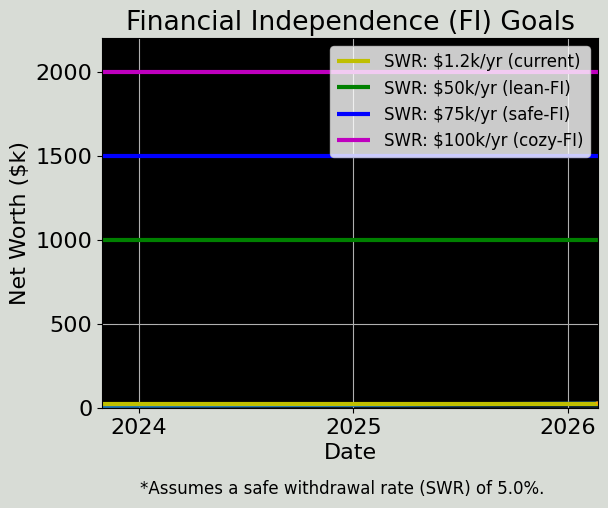

In [9]:
# FI Goals - These are the only hardcoded values you should adjust
# All values are annual withdrawal amounts in thousands ($1k)

swr = 0.05           # Safe withdrawal rate (5%)
lean_swr = 50        # Lean FI: $50k/year
safe_swr = 75        # Safe FI: $75k/year
cozy_swr = 100       # Cozy FI: $100k/year

# Plot FI goals
plot_fi_goals(net_worth_list,
              date_list,
              swr=swr,
              lean_swr=lean_swr,
              safe_swr=safe_swr,
              cozy_swr=cozy_swr,
              end_date=datetime.today())

### Plot Net Worth

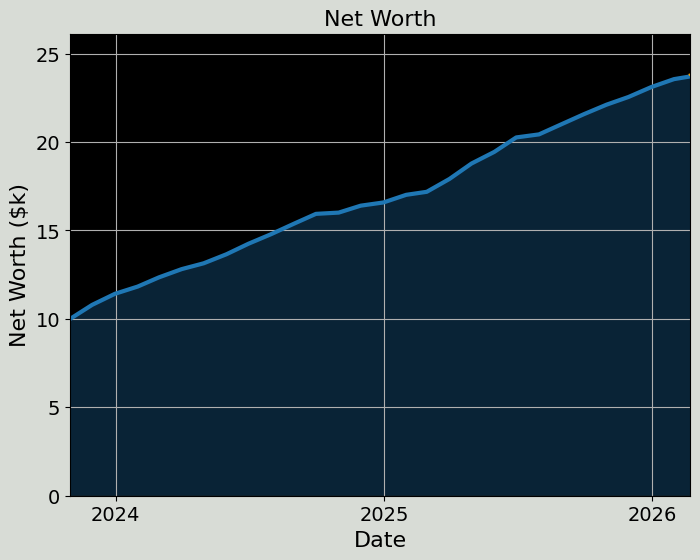

In [10]:
# Plot net worth over time
plot_net_worth(date_list, net_worth_list, end_date=datetime.today())

### FI Goal Forecast

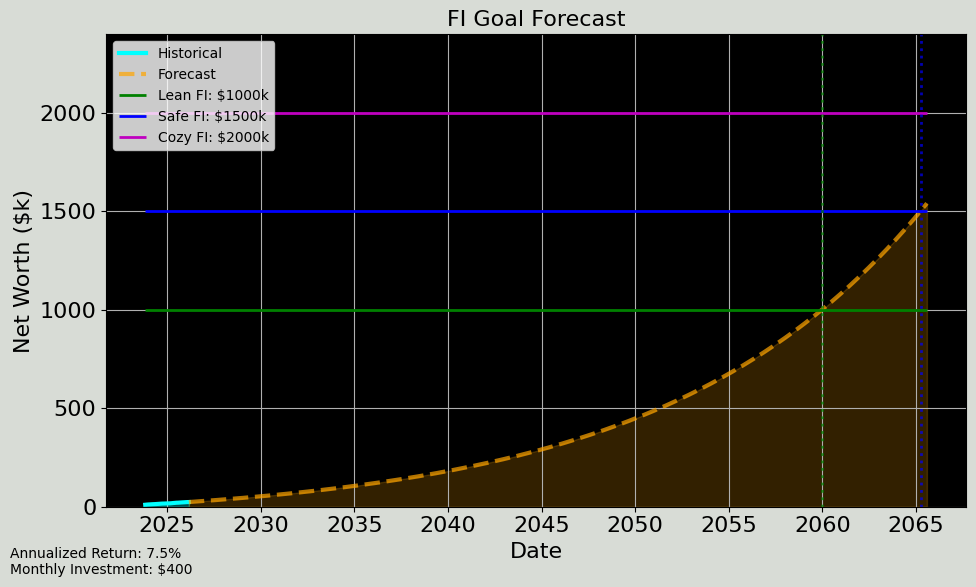


=== FI Goal Forecast ===
Current Net Worth: $23.7k
Historical Annualized Return: 7.5%
Monthly Investment: $400

Goal Achievement Dates:
  Lean FI ($1000k): 2060-01-01
  Safe FI ($1500k): 2065-04-04
  Cozy FI ($2000k): Not within forecast period


In [11]:
# Plot FI forecast showing when goals will be reached
lean_date, safe_date, cozy_date = plot_fi_forecast(
    net_worth_list,
    date_list,
    monthly_investment=monthly_investment,
    annualized_return=annualized_return,
    swr=swr,
    lean_swr=lean_swr,
    safe_swr=safe_swr,
    cozy_swr=cozy_swr,
    forecast_years=40
)

### FI Goal Forecast with Custom Annualized Return

This chart uses a custom annualized return rate defined in `my_portfolio.py` instead of the historical return. This allows you to model different scenarios with more conservative or optimistic return assumptions.

Custom return not found, using default: 7.0%


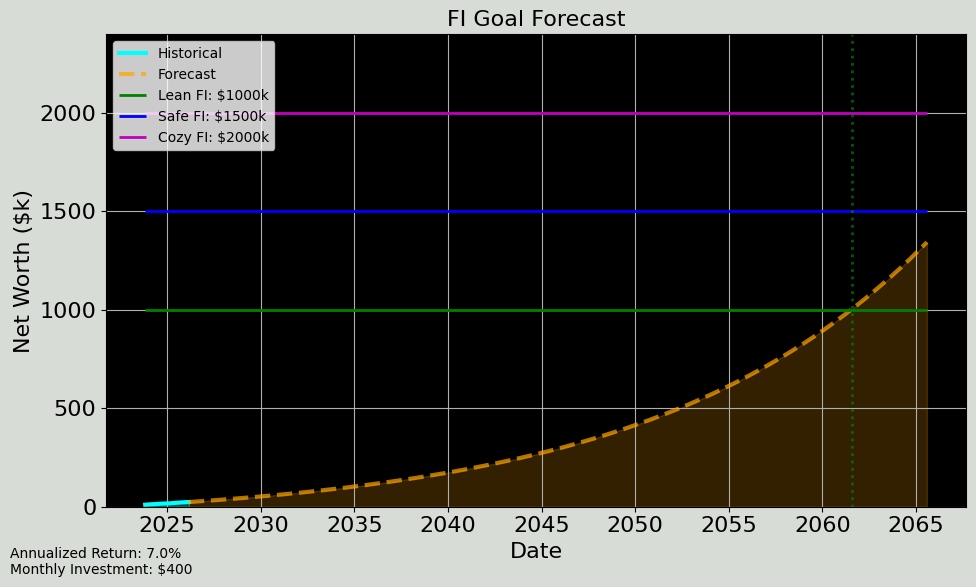


=== FI Goal Forecast ===
Current Net Worth: $23.7k
Historical Annualized Return: 7.0%
Monthly Investment: $400

Goal Achievement Dates:
  Lean FI ($1000k): 2061-07-24
  Safe FI ($1500k): Not within forecast period
  Cozy FI ($2000k): Not within forecast period


In [ ]:
# Use custom annualized return from my_portfolio.py if available
try:
    custom_return = custom_annualized_return
    print(f"Using custom annualized return: {custom_return*100:.1f}%")
except NameError:
    custom_return = 0.07  # Default to 7% if not defined
    print(f"Custom return not found, using default: {custom_return*100:.1f}%")

# Plot FI forecast with custom return rate
lean_date_custom, safe_date_custom, cozy_date_custom = plot_fi_forecast(
    net_worth_list,
    date_list,
    monthly_investment=monthly_investment,
    annualized_return=custom_return,
    swr=swr,
    lean_swr=lean_swr,
    safe_swr=safe_swr,
    cozy_swr=cozy_swr,
    forecast_years=40
)